# MatMul 测试

#### Import all headers
Notably, tensorflow requires much lower python version than 3.11
We take python 3.11 to use the higher version of IREE, which is more comparable between compiler backends with other SOTAs.

In [1]:
import numpy as np
import torch
import jax
import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import timeit
start_time = timeit.timeit()

#### Invoke ragdoll-opt to generate backward ir
use following passes
* --autodiff: the pipeline to generate inlined backward function for given operator

Note: comments is matmul.mlir

In [2]:
#matmul_tosa_ir = """
#module {
#  func.func @matmul(%arg0: tensor<1x500x1000xf32>, %arg1: tensor<1x1000x500xf32>) -> tensor<1x500x500xf32> {
#    %0 = tosa.matmul %arg0, %arg1 : (tensor<1x500x1000xf32>, tensor<1x1000x500xf32>) -> tensor<1x500x500xf32>
#    return %0 : tensor<1x500x500xf32>
#  }
#}
#"""

!cat ../operator-cases/matmul.mlir
!../../build/bin/ragdoll-opt \
    ../operator-cases/matmul.mlir \
    --pass-pipeline="builtin.module(func.func(tosa-to-linalg-named, linalg-generalize-named-ops))" > ../../build/matmul.mlir.linalg
!cat ../../build/.matmul.mlir.linalg
    
!../../build/bin/ragdoll-opt \
    ../../build/matmul.mlir.linalg \
    --ragdoll-autodiff \
    --ragdoll-autodiff-inline-function-call \
    --ragdoll-initialisation \
    --ragdoll-legalise-to-iree-compatibility > ../../build/.matmul.mlir.stage1

!../../build/bin/ragdoll-opt \
    ../../build/.matmul.mlir.stage1 \
    --ragdoll-remove-globals \
    --canonicalize \
    --cse \
    > ../../build/.matmul.mlir.stage2
!cat ../../build/.matmul.mlir.stage1
!cat ../../build/.matmul.mlir.stage2

module {
  func.func @matmul(%arg0: tensor<4x512x1024xf32>, %arg1: tensor<4x1024x512xf32>) -> tensor<4x512x512xf32> {
    %0 = tosa.matmul %arg0, %arg1 : (tensor<4x512x1024xf32>, tensor<4x1024x512xf32>) -> tensor<4x512x512xf32>
    return %0 : tensor<4x512x512xf32>
  }
}
module {
  func.func @matmul(%arg0: tensor<8x512x1024xf32>, %arg1: tensor<8x1024x512xf32>) -> tensor<8x512x512xf32> {
    %cst = arith.constant 0.000000e+00 : f32
    %0 = tensor.empty() : tensor<8x512x512xf32>
    %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<8x512x512xf32>) -> tensor<8x512x512xf32>
    %2 = linalg.batch_matmul ins(%arg0, %arg1 : tensor<8x512x1024xf32>, tensor<8x1024x512xf32>) outs(%1 : tensor<8x512x512xf32>) -> tensor<8x512x512xf32>
    return %2 : tensor<8x512x512xf32>
  }
}

#map = affine_map<(d0, d1, d2) -> ()>
#map1 = affine_map<(d0, d1, d2) -> (d0, d1, d2)>
#map2 = affine_map<(d0, d1, d2, d3) -> (d0, d1, d3)>
#map3 = affine_map<(d0, d1, d2, d3) -> (d0, d3, d2)>
#map4 = affine_map<(d0, d1, d2

In [3]:
expected_ir = """
module {
  func.func @matmul(%arg0: tensor<1x500x1000xf32>, %arg1: tensor<1x1000x500xf32>) -> tensor<1x500x500xf32> {
    %0 = "tosa.matmul"(%arg0, %arg1) : (tensor<1x500x1000xf32>, tensor<1x1000x500xf32>) -> tensor<1x500x500xf32>
    return %0 : tensor<1x500x500xf32>
  }
  func.func @dmatmul(%arg0: tensor<1x500x1000xf32>, %arg1: tensor<1x1000x500xf32>, %arg2: tensor<1x500x500xf32>) -> (tensor<1x500x1000xf32>, tensor<1x1000x500xf32>) {
    %0 = "tosa.const"() {value = dense<[0, 2, 1]> : tensor<3xi32>} : () -> tensor<3xi32>
    %1 = "tosa.transpose"(%arg1, %0) : (tensor<1x1000x500xf32>, tensor<3xi32>) -> tensor<1x500x1000xf32>
    %2 = "tosa.matmul"(%arg2, %1) : (tensor<1x500x500xf32>, tensor<1x500x1000xf32>) -> tensor<1x500x1000xf32>
    %3 = "tosa.transpose"(%arg0, %0) : (tensor<1x500x1000xf32>, tensor<3xi32>) -> tensor<1x1000x500xf32>
    %4 = "tosa.matmul"(%3, %arg2) : (tensor<1x1000x500xf32>, tensor<1x500x500xf32>) -> tensor<1x1000x500xf32>
    return %2, %4 : tensor<1x500x1000xf32>, tensor<1x1000x500xf32>
  }
}
"""
generated_ir = open('../../build/.matmul.mlir.stage2').read()
print(generated_ir)
# print(expected_ir)
#assert(expected_ir == open('../../build/.matmul.mlir.stage2').read())

#map = affine_map<(d0, d1, d2) -> ()>
#map1 = affine_map<(d0, d1, d2) -> (d0, d1, d2)>
#map2 = affine_map<(d0, d1, d2, d3) -> (d0, d1, d3)>
#map3 = affine_map<(d0, d1, d2, d3) -> (d0, d3, d2)>
#map4 = affine_map<(d0, d1, d2, d3) -> (d0, d1, d2)>
module {
  func.func @matmul(%arg0: tensor<4x512x1024xf32>, %arg1: tensor<4x1024x512xf32>) -> (tensor<4x512x512xf32>, tensor<4x512x1024xf32>, tensor<4x1024x512xf32>) {
    %cst = arith.constant dense<0.000000e+00> : tensor<4x512x512xf32>
    %cst_0 = arith.constant 0.000000e+00 : f32
    %0 = linalg.generic {indexing_maps = [#map, #map1], iterator_types = ["parallel", "parallel", "parallel"]} ins(%cst_0 : f32) outs(%cst : tensor<4x512x512xf32>) {
    ^bb0(%in: f32, %out: f32):
      linalg.yield %in : f32
    } -> tensor<4x512x512xf32>
    %1 = linalg.generic {indexing_maps = [#map2, #map3, #map4], iterator_types = ["parallel", "parallel", "parallel", "reduction"]} ins(%arg0, %arg1 : tensor<4x512x1024xf32>, tensor<4x1024x512xf32>) outs(%0 : ten

1. Compile the input tosa ir into iree modules

drivers = iree.runtime.query_available_drivers()
drivers
iree.runtime.get_driver("cuda")

In [4]:
from functools import wraps
from time import perf_counter
from collections import namedtuple

TimerResult = namedtuple("TimerResult", ("result", "timecost"))

def timer(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = perf_counter()
        res = func(*args, **kwargs)
        end = perf_counter()
        return TimerResult(res, end - start)
    return wrapper

def iree_compile(module):
    #binary = iree.compiler.tools.compile_str(
    #    module, input_type="tosa", target_backends=["llvm-cpu"]
    #)
    binary = iree.compiler.tools.compile_str(
        module, input_type="tosa", target_backends=["cuda"]
    )
    #CPU
    #config = iree.runtime.system_api.Config("local-task")
    #GPU
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

In [5]:
# expected_iree_module = iree_compile(expected_ir)
generated_iree_module = iree_compile(generated_ir)

/tmp/ipykernel_2101278/847917488.py:28: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary)


2. 为每个库编写测试函数

In [6]:
print('TensorFlow was built with CUDA support' if tf.test.is_built_with_cuda() else 'TensorFlow was not built with CUDA support'); print('CUDA is available' if tf.config.list_physical_devices('GPU') else 'CUDA is not available')

TensorFlow was built with CUDA support
CUDA is available


In [7]:
TestResult = namedtuple("TestResult", ("res", "dlhs", "drhs", "forward_timecost", "backward_timecost"))

def torch_test(lhs, rhs, dres):
    lhs, rhs, dres = [torch.from_numpy(i) for i in [lhs, rhs, dres]]
    lhs.requires_grad = True
    rhs.requires_grad = True
    
    @timer
    def forward():
        return torch.bmm(lhs, rhs)
    
    @timer
    def backward(res):
        res.backward(dres)
        return lhs.grad, rhs.grad
    
    res, forward_timecost = forward()
    (dlhs, drhs), backward_timecost = backward(res)
    
    return TestResult(res, dlhs, drhs, forward_timecost, backward_timecost)

def jax_test(lhs, rhs, dres):
    lhs, rhs, dres = [jnp.array(i) for i in [lhs, rhs, dres]]
    
    @timer
    def forward():
        return jax.lax.batch_matmul(lhs, rhs)
    
    res, grad = jax.vjp(jax.lax.batch_matmul, lhs, rhs) # not counted
    
    @timer
    def backward():
        return grad(dres)
    
    res, forward_timecost = forward()
    (dlhs, drhs), backward_timecost = backward()
    
    return TestResult(res, dlhs, drhs, forward_timecost, backward_timecost)

def tf_test(lhs, rhs, dres):
    lhs, rhs, dres = [tf.convert_to_tensor(i) for i in [lhs, rhs, dres]]
    
    @timer
    def forward():
        return tf.matmul(lhs, rhs)
    
    @timer
    def backward(tape, target):
        return tape.gradient(target, lhs, dres), tape.gradient(target, rhs, dres)
        
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(lhs)
        tape.watch(rhs)
        res, forward_timecost = forward()
        (dlhs, drhs), backward_timecost = backward(tape, res)
        
    return TestResult(res, dlhs, drhs, forward_timecost, backward_timecost)

def iree_test(lhs, rhs, dres):
    @timer
    def forward():
        return generated_iree_module["matmul"](lhs, rhs)[0]
    
    @timer
    def backward():
        dlhs, drhs = generated_iree_module["dmatmul"](dres, lhs, rhs)
        return dlhs, drhs
    
    res, forward_timecost = forward()
    (dlhs, drhs), backward_timecost = backward()
    return TestResult(res, dlhs, drhs, forward_timecost, backward_timecost)
def test_all_ntimes(n):
    lhs_list = [np.random.randn(4, 512, 1024).astype(np.float32) for _ in range(n)]
    rhs_list = [np.random.randn(4, 1024, 512).astype(np.float32) for _ in range(n)]
    dres_list = [np.random.randn(4, 512, 512).astype(np.float32) for _ in range(n)]
    
    def test(func):
        test_results = []
        for lhs, rhs, dres in zip(lhs_list, rhs_list, dres_list):
            test_results.append(func(lhs, rhs, dres))
        return test_results
    iree_result = test(iree_test)
    torch_result = test(torch_test)
    jax_result = test(jax_test)
    tf_result = test(tf_test)
    return torch_result, tf_result, iree_result
    
def test_ntimes(test_entry, n):
    lhs_list = [np.random.randn(4, 512, 1024).astype(np.float32) for _ in range(n)]
    rhs_list = [np.random.randn(4, 1024, 512).astype(np.float32) for _ in range(n)]
    dres_list = [np.random.randn(4, 512, 512).astype(np.float32) for _ in range(n)]
    
    def test(func):
        test_results = []
        for lhs, rhs, dres in zip(lhs_list, rhs_list, dres_list):
            test_results.append(func(lhs, rhs, dres))
        return test_results
    return test(test_entry),
    #return test(torch_test), test(jax_test), test(iree_test)
    #return test(torch_test), test(jax_test), test(tf_test), test(iree_test)

3. 进行测试

In [8]:
N = 17

# torch_res, jax_res, tf_res, iree_tres = test_ntimes(N)
# PY38, jax is broken
# names = ["torch"]
# names = ["torch", "jax", "tensorflow", "iree"]
names = ["torch", "tensorflow", "iree"]
results = test_all_ntimes(N)
#torch_results = test_ntimes(torch_test, N)
# results = test_ntimes(tf_test, N)
#results = torch_results, tf_results

In [9]:
# remove warm up loops
def get_forward_array(res):
    return np.array(list(map(lambda x : x.forward_timecost, res)))[2:]

def get_backward_array(res):
    return np.array(list(map(lambda x : x.backward_timecost, res)))[2:]

forward_line = pd.DataFrame(dict(zip(names, [get_forward_array(res) for res in results])))
backward_line = pd.DataFrame(dict(zip(names, [get_backward_array(res) for res in results])))
total_line = pd.DataFrame(dict(zip(names, [get_backward_array(res) + get_forward_array(res) for res in results])))

forward_bar = pd.DataFrame(dict(zip(names, [[sum(get_forward_array(res))] for res in results])))
backward_bar = pd.DataFrame(dict(zip(names, [[sum(get_backward_array(res))] for res in results])))
total_bar = pd.DataFrame(dict(zip(names, [[sum(get_backward_array(res) + get_forward_array(res))] for res in results])))

4. 输出测试结果

In [10]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

* 正向过程用时

Text(0.5, 0.98, 'forward pass')

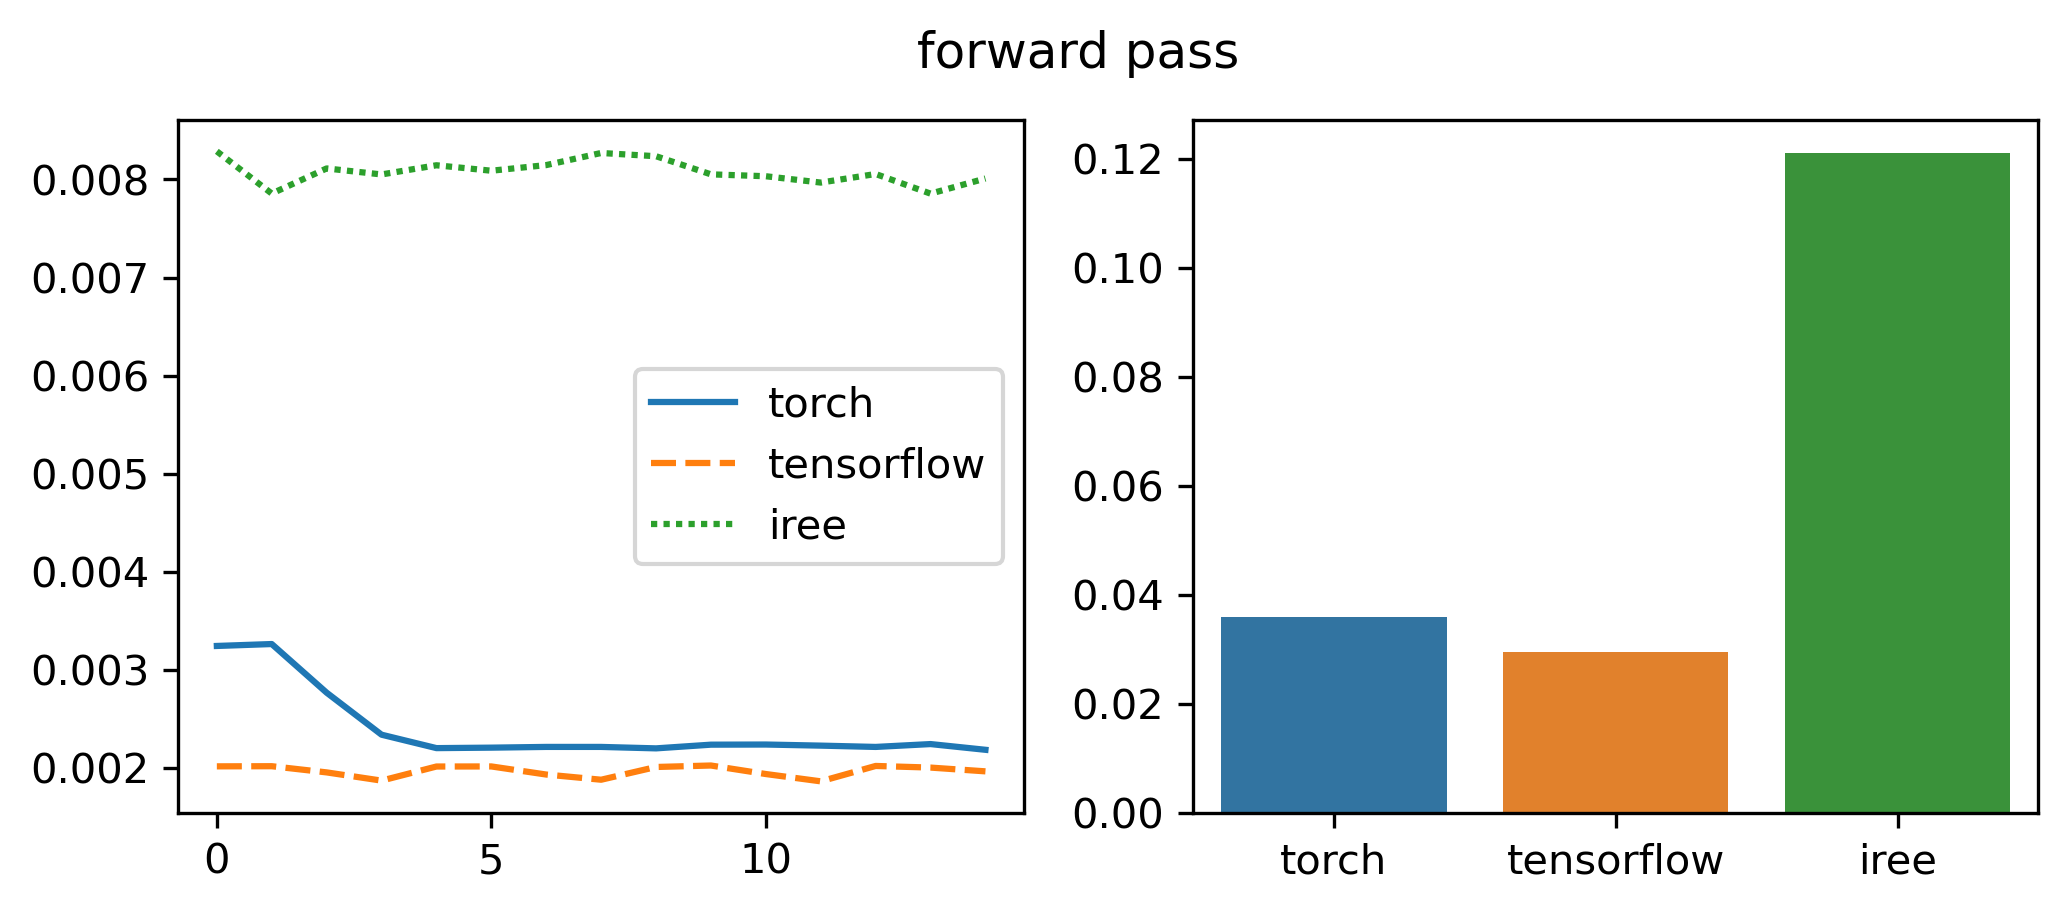

In [11]:
fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(forward_line, ax=left)
sns.barplot(forward_bar, ax=right)
plt.suptitle("forward pass")

* 反向过程用时

Text(0.5, 0.98, 'backward pass')

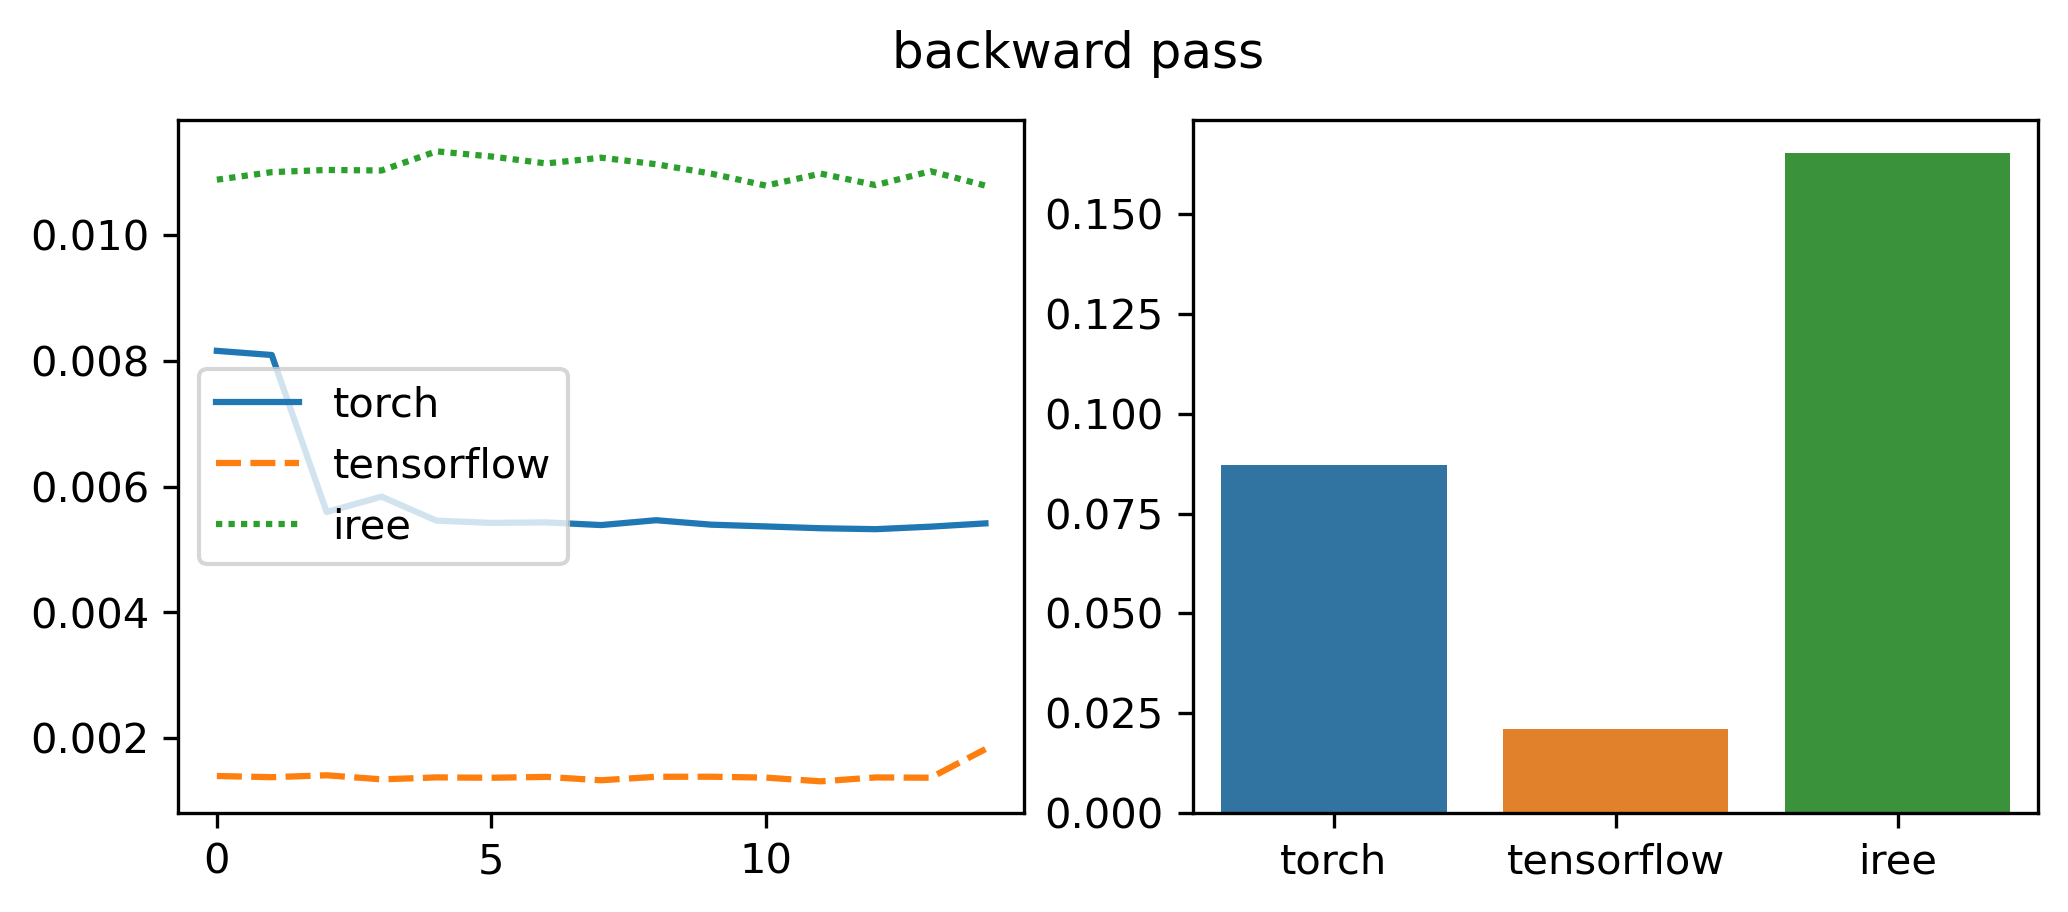

In [12]:
fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(backward_line, ax=left)
sns.barplot(backward_bar, ax=right)
plt.suptitle("backward pass")

* 总用时

Text(0.5, 0.98, 'total time')

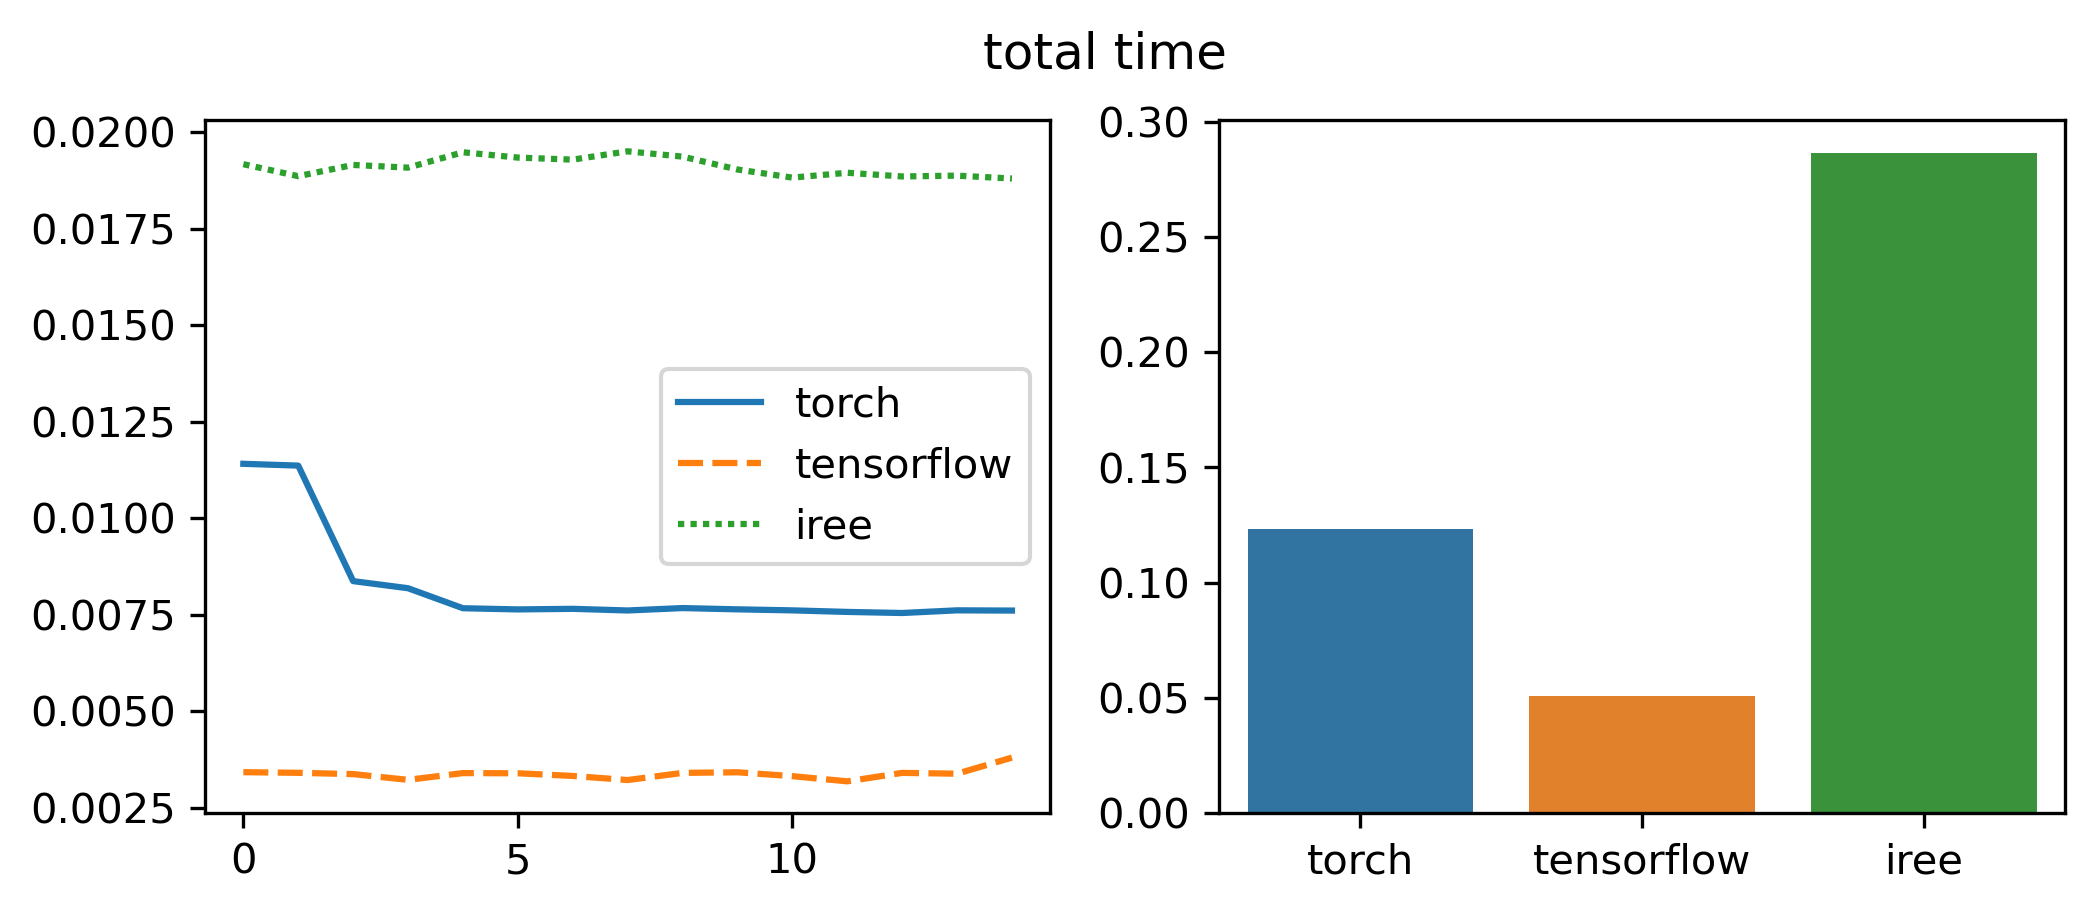

In [13]:
fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(total_line, ax=left)
sns.barplot(total_bar, ax=right)
plt.suptitle("total time")

In [14]:
end_time = timeit.timeit()
print("total time = ", end_time - start_time)

total time =  0.00016162730753421783
